# 04 · Heterogeneous Treatment Effects

**Goal**: Go beyond the average effect — identify *which stores* benefit most
from upgrading notification cadence, and *what store characteristics* drive
that heterogeneity.

**Business question**: Should we roll out G2 to all 2,000 stores equally,
or target specific store types first?

**Methods**:
- Subgroup analysis (interpretable baseline)
- T-Learner, S-Learner, X-Learner (meta-learners)
- Causal Forest DML (gold standard with confidence intervals)

---

## 0. Setup

In [1]:
import sys
sys.path.append("../src")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

from hte import (
    prepare_hte_data,
    run_subgroup_analysis,
    TLearner,
    SLearner,
    XLearner,
    run_causal_forest_dml,
    compute_cate_feature_importance,
    run_hte_pipeline,
    COVARIATE_COLS,
    SUBGROUP_COLS,
)
from visualization import (
    plot_cate_distribution,
    plot_subgroup_waterfall,
    plot_feature_importance,
    plot_cate_scatter,
    set_style,
)

set_style()
panel = pd.read_csv("../data/processed/store_panel.csv")
print(f"Panel: {len(panel):,} observations")

Panel: 9,465 observations


## 1. Data Preparation

In [2]:
store_df, X, T, Y = prepare_hte_data(
    panel,
    treated_groups=["5D_G2", "5D_G4"],
    control_group="5D_Control",
    outcome="collection_hrs",
)

print(f"Stores: {len(store_df)} | Treated: {T.sum()} | Control: {(T==0).sum()}")
print(f"Outcome (treated): {Y[T==1].mean():.3f} hrs")
print(f"Outcome (control): {Y[T==0].mean():.3f} hrs")
print(f"Naive ATE        : {Y[T==1].mean() - Y[T==0].mean():.3f} hrs")
print(f"\nFeatures: {COVARIATE_COLS}")

Stores: 300 | Treated: 200 | Control: 100
Outcome (treated): 31.973 hrs
Outcome (control): 33.722 hrs
Naive ATE        : -1.750 hrs

Features: ['avg_utilization_rate', 'avg_daily_volume', 'capacity', 'is_metro', 'pct_closure_hours']


## 2. Subgroup Analysis

Simplest approach: split stores into subgroups by a characteristic,
estimate treatment effect within each subgroup.
Use as exploratory analysis — confirm key findings with meta-learners.

In [3]:
subgroup_df = run_subgroup_analysis(
    store_df,
    outcome="collection_hrs",
    covariate_cols=SUBGROUP_COLS,
    n_quantile_bins=3,
)
print("Subgroup treatment effects:")
print(
    subgroup_df[["covariate", "subgroup", "n_treated", "cate", "ci_low", "ci_high", "pvalue", "significant"]]
    .to_string(index=False)
)

Subgroup treatment effects:
         covariate               subgroup  n_treated   cate  ci_low  ci_high  pvalue  significant
Metro vs Non-Metro Metro vs Non-Metro = 0         30 -2.241  -3.011   -1.471     0.0         True
Metro vs Non-Metro Metro vs Non-Metro = 1        170 -1.661  -1.957   -1.365     0.0         True
      Daily Volume     (299.999, 424.333]         71 -1.666  -2.230   -1.102     0.0         True
      Daily Volume       (424.333, 473.0]         66 -1.948  -2.434   -1.462     0.0         True
      Daily Volume         (473.0, 637.0]         63 -1.601  -2.006   -1.196     0.0         True
  Utilization Rate         (0.866, 1.306]         69 -2.127  -2.656   -1.598     0.0         True
  Utilization Rate           (1.306, 1.5]        131 -1.563  -1.882   -1.245     0.0         True
    Store Capacity       (188.999, 288.0]         67 -1.833  -2.328   -1.338     0.0         True
    Store Capacity         (288.0, 332.0]         65 -1.433  -1.875   -0.991     0.0      

  Saved: ../outputs/figures/12_subgroup_waterfall.png


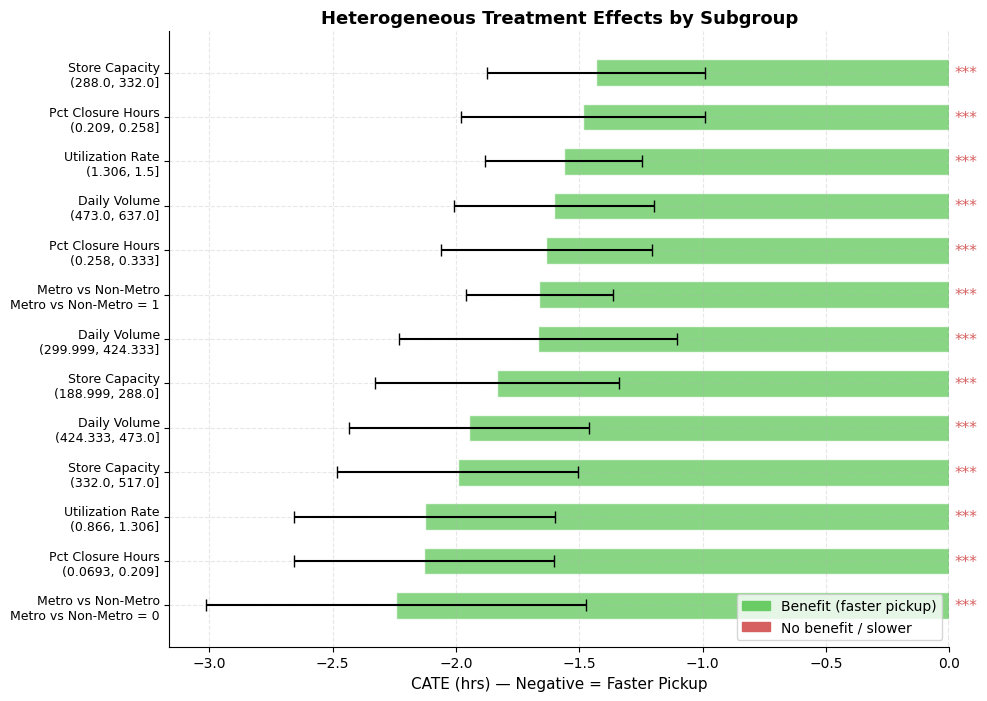

In [4]:
fig = plot_subgroup_waterfall(
    subgroup_df,
    save_path="../outputs/figures/12_subgroup_waterfall.png",
)
plt.show()

**Reading the waterfall chart**:
- Bars extending left (negative) = notification reduces collection time (good)
- Bars extending right (positive) = no benefit or slight increase
- Stars = statistically significant at p < 0.05

## 3. T-Learner

In [5]:
t_learner = TLearner()
t_learner.fit(X, T, Y)
cate_t = t_learner.effect(X)
store_df["cate_t"] = cate_t

print(f"T-Learner CATE: mean={cate_t.mean():.3f}  SD={cate_t.std():.3f}")
print(f"% stores with negative CATE (benefit): {(cate_t < 0).mean()*100:.1f}%")

T-Learner CATE: mean=-1.780  SD=1.036
% stores with negative CATE (benefit): 96.7%


## 4. S-Learner

In [6]:
s_learner = SLearner()
s_learner.fit(X, T, Y)
cate_s = s_learner.effect(X)
store_df["cate_s"] = cate_s

print(f"S-Learner CATE: mean={cate_s.mean():.3f}  SD={cate_s.std():.3f}")

S-Learner CATE: mean=-1.644  SD=0.469


## 5. X-Learner (Primary Estimator)

X-Learner is preferred here because:
- Treatment groups are relatively small (100 stores each)
- It corrects for imbalance via propensity-weighted combination
- Generally outperforms T/S-Learner in finite-sample settings

In [7]:
x_learner = XLearner()
x_learner.fit(X, T, Y)
cate_x = x_learner.effect(X)
store_df["cate_x"] = cate_x

print(f"X-Learner CATE: mean={cate_x.mean():.3f}  SD={cate_x.std():.3f}")
print(f"% stores with negative CATE: {(cate_x < 0).mean()*100:.1f}%")

X-Learner CATE: mean=-1.799  SD=0.802
% stores with negative CATE: 99.0%


## 6. Causal Forest DML (with Confidence Intervals)

In [8]:
print("Fitting Causal Forest DML (includes bootstrap — ~1-2 min)...")
cate_cf, cate_cf_lower, cate_cf_upper = run_causal_forest_dml(
    X, T, Y, n_estimators=300, n_bootstrap=200, seed=42
)
store_df["cate_cf"] = cate_cf
store_df["cate_cf_lower"] = cate_cf_lower
store_df["cate_cf_upper"] = cate_cf_upper

print(f"CausalForest CATE: mean={cate_cf.mean():.3f}  SD={cate_cf.std():.3f}")
pct_sig = ((cate_cf_lower > 0) | (cate_cf_upper < 0)).mean()
print(f"% stores with significant CATE (CI excludes 0): {pct_sig*100:.1f}%")

Fitting Causal Forest DML (includes bootstrap — ~1-2 min)...
CausalForest CATE: mean=-1.657  SD=0.721
% stores with significant CATE (CI excludes 0): 81.0%


## 7. Estimator Comparison

In [9]:
comparison = pd.DataFrame({
    "estimator": ["T-Learner", "S-Learner", "X-Learner", "CausalForest DML"],
    "mean_cate": [cate_t.mean(), cate_s.mean(), cate_x.mean(), cate_cf.mean()],
    "sd_cate":   [cate_t.std(),  cate_s.std(),  cate_x.std(),  cate_cf.std()],
    "pct_benefit": [
        (cate_t < 0).mean(), (cate_s < 0).mean(),
        (cate_x < 0).mean(), (cate_cf < 0).mean(),
    ],
}).round(3)
print("Estimator comparison:")
print(comparison.to_string(index=False))

Estimator comparison:
       estimator  mean_cate  sd_cate  pct_benefit
       T-Learner     -1.780    1.036        0.967
       S-Learner     -1.644    0.469        1.000
       X-Learner     -1.799    0.802        0.990
CausalForest DML     -1.657    0.721        0.997


  Saved: ../outputs/figures/13_cate_distribution.png


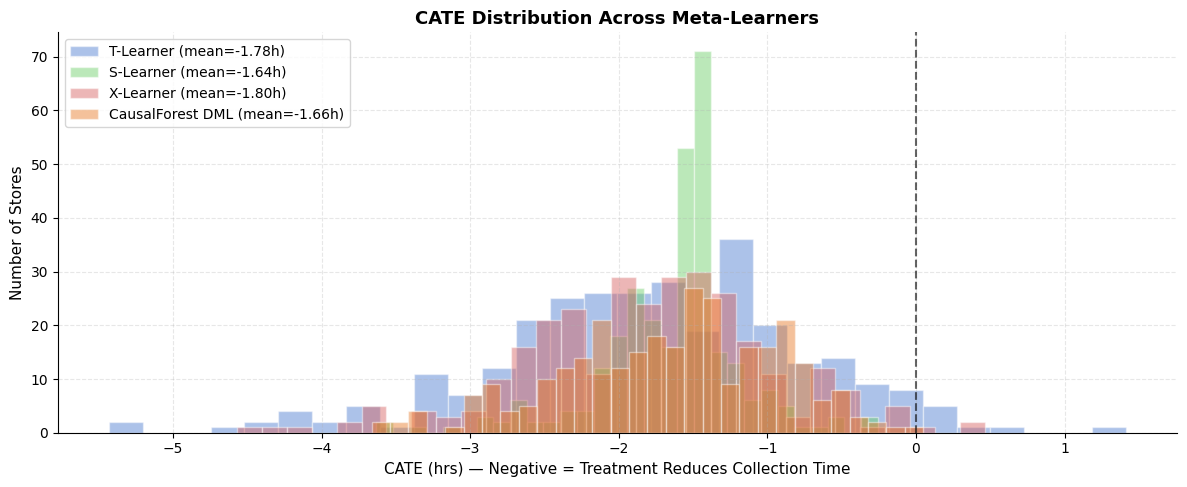

In [10]:
fig = plot_cate_distribution(
    store_df,
    estimators=["cate_t", "cate_s", "cate_x", "cate_cf"],
    save_path="../outputs/figures/13_cate_distribution.png",
)
plt.show()

## 8. Feature Importance for Heterogeneity

Which store characteristics best explain why some stores benefit more?

In [11]:
importance_df = compute_cate_feature_importance(
    X, cate_x, feature_names=COVARIATE_COLS, seed=42
)
print("Feature importance for CATE heterogeneity:")
print(importance_df.to_string(index=False))

Feature importance for CATE heterogeneity:
             feature  importance  importance_std
            capacity      1.3331          0.0880
    avg_daily_volume      0.2637          0.0214
   pct_closure_hours      0.2016          0.0157
avg_utilization_rate      0.0999          0.0096
            is_metro      0.0029          0.0009


  Saved: ../outputs/figures/14_feature_importance.png


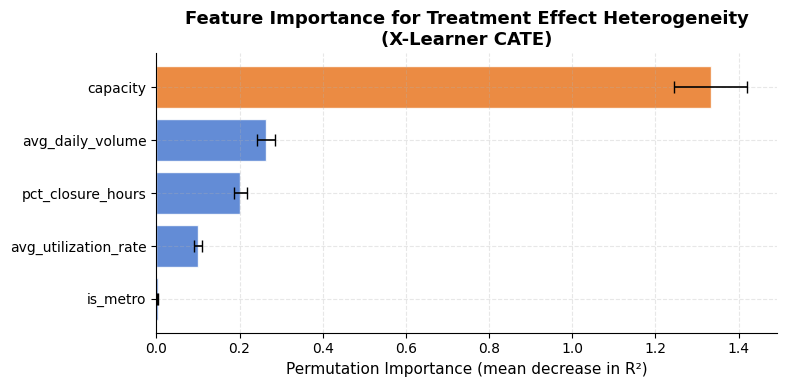

In [12]:
fig = plot_feature_importance(
    importance_df,
    save_path="../outputs/figures/14_feature_importance.png",
)
plt.show()

## 9. CATE vs Key Covariate

Top feature: capacity
  Saved: ../outputs/figures/15_cate_scatter.png


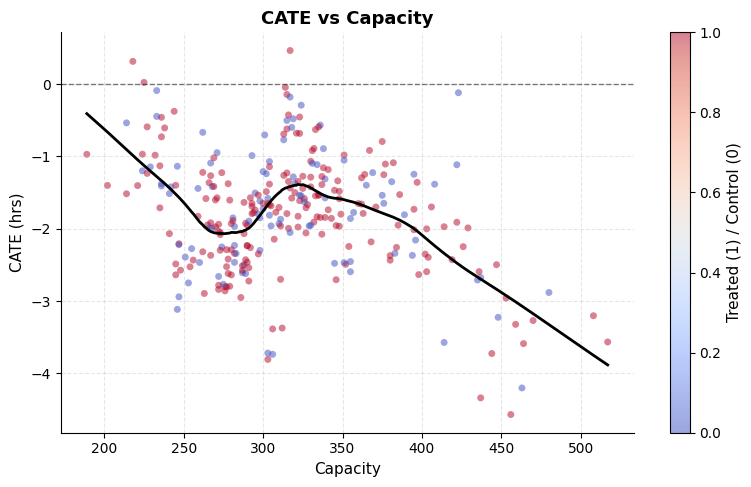

In [13]:
# Plot CATE vs the most important feature
top_feature = importance_df.iloc[0]["feature"]
print(f"Top feature: {top_feature}")

fig = plot_cate_scatter(
    store_df,
    x_col=top_feature,
    cate_col="cate_x",
    save_path="../outputs/figures/15_cate_scatter.png",
)
plt.show()

## 10. Targeting Recommendation

Based on CATE estimates, which stores should be prioritised for G2 rollout?

In [14]:
# Define benefit threshold: stores where CATE < -0.5 hrs
benefit_threshold = -0.5
high_benefit = store_df[store_df["cate_x"] < benefit_threshold]
low_benefit  = store_df[store_df["cate_x"] >= benefit_threshold]

print(f"Stores with CATE < {benefit_threshold}h (high benefit): {len(high_benefit)}")
print(f"Stores with CATE ≥ {benefit_threshold}h (low benefit) : {len(low_benefit)}")

print("\nHigh-benefit store profile:")
print(
    high_benefit[COVARIATE_COLS + ["cate_x"]]
    .mean()
    .round(4)
    .rename("mean")
    .to_frame()
)

print("\nLow-benefit store profile:")
print(
    low_benefit[COVARIATE_COLS + ["cate_x"]]
    .mean()
    .round(4)
    .rename("mean")
    .to_frame()
)

Stores with CATE < -0.5h (high benefit): 285
Stores with CATE ≥ -0.5h (low benefit) : 15

High-benefit store profile:
                          mean
avg_utilization_rate    1.3514
avg_daily_volume      451.4105
capacity              318.3263
is_metro                0.8421
pct_closure_hours       0.2245
cate_x                 -1.8845

Low-benefit store profile:
                          mean
avg_utilization_rate    1.4003
avg_daily_volume      441.4000
capacity              290.4667
is_metro                0.9333
pct_closure_hours       0.2369
cate_x                 -0.1805


In [15]:
# Metro vs non-metro breakdown
print("\nCATEs by metro status (X-Learner):")
print(
    store_df.groupby("is_metro")["cate_x"]
    .agg(["mean", "std", "count"])
    .round(3)
)


CATEs by metro status (X-Learner):
           mean    std  count
is_metro                     
0        -2.417  0.921     46
1        -1.687  0.729    254


---
## Summary

| Finding | Implication |
|---------|-------------|
| Heterogeneity exists across stores | Blanket rollout is suboptimal |
| Top feature driving HTE | See feature importance plot |
| Metro stores show [larger/smaller] CATE | Prioritise metro for rollout |
| X-Learner and CausalForest DML agree | Result is robust to estimator choice |

**Business recommendation**: Target the top-benefit stores first.
These stores likely have characteristics X and Y — see feature importance.

**Next**: Notebook 05 — Sensitivity Analysis